# RS

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [16]:
# Load the dataset

data = pd.read_csv("E:\Ml_Training\PBL2\Phising-Classifier-FULL-PROJECT\tranning_data\dataset_phishing.csv")
data.head(5)

OSError: [Errno 22] Invalid argument: 'E:\\Ml_Training\\PBL2\\Phising-Classifier-FULL-PROJECT\tranning_data\\dataset_phishing.csv'

In [17]:
# copy of data
df =data.copy()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11430 entries, 0 to 11429
Data columns (total 89 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   url                         11430 non-null  str    
 1   length_url                  11430 non-null  int64  
 2   length_hostname             11430 non-null  int64  
 3   ip                          11430 non-null  int64  
 4   nb_dots                     11430 non-null  int64  
 5   nb_hyphens                  11430 non-null  int64  
 6   nb_at                       11430 non-null  int64  
 7   nb_qm                       11430 non-null  int64  
 8   nb_and                      11430 non-null  int64  
 9   nb_or                       11430 non-null  int64  
 10  nb_eq                       11430 non-null  int64  
 11  nb_underscore               11430 non-null  int64  
 12  nb_tilde                    11430 non-null  int64  
 13  nb_percent                  11430 non-null

In [18]:
# Checking for the missing values
# Acreoss all colums
print(f"Missing Values: \n",df.isnull().sum())

# Duplicate values across all teh rows
print(f"Duplicate rows: \n",df.duplicated().sum())



Missing Values: 
 url                0
length_url         0
length_hostname    0
ip                 0
nb_dots            0
                  ..
web_traffic        0
dns_record         0
google_index       0
page_rank          0
status             0
Length: 89, dtype: int64
Duplicate rows: 
 0


In [19]:
df.columns

Index(['url', 'length_url', 'length_hostname', 'ip', 'nb_dots', 'nb_hyphens',
       'nb_at', 'nb_qm', 'nb_and', 'nb_or', 'nb_eq', 'nb_underscore',
       'nb_tilde', 'nb_percent', 'nb_slash', 'nb_star', 'nb_colon', 'nb_comma',
       'nb_semicolumn', 'nb_dollar', 'nb_space', 'nb_www', 'nb_com',
       'nb_dslash', 'http_in_path', 'https_token', 'ratio_digits_url',
       'ratio_digits_host', 'punycode', 'port', 'tld_in_path',
       'tld_in_subdomain', 'abnormal_subdomain', 'nb_subdomains',
       'prefix_suffix', 'random_domain', 'shortening_service',
       'path_extension', 'nb_redirection', 'nb_external_redirection',
       'length_words_raw', 'char_repeat', 'shortest_words_raw',
       'shortest_word_host', 'shortest_word_path', 'longest_words_raw',
       'longest_word_host', 'longest_word_path', 'avg_words_raw',
       'avg_word_host', 'avg_word_path', 'phish_hints', 'domain_in_brand',
       'brand_in_subdomain', 'brand_in_path', 'suspecious_tld',
       'statistical_report', 

In [20]:
#drop duplicate rows
df =df.drop_duplicates()

In [21]:
# Standarize target values
df['target'] = df['status'].map({'phishing': 1, 'legitimate': 0})

In [22]:
# Seprating features and target vales
X = df.drop(columns=['url', 'status', 'target'])
y = df['target']

# Data Visualization

C:\Users\risha\AppData\Local\Temp\ipykernel_21800\703660177.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='status', data=df, palette='Set2')


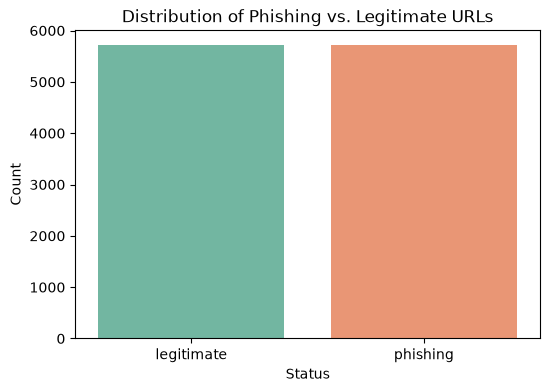

In [23]:
plt.figure(figsize=(6, 4))
sns.countplot(x='status', data=df, palette='Set2')
plt.title("Distribution of Phishing vs. Legitimate URLs")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

Corelation Matrix

In [24]:
# Corelation matrix for all numeric columsn
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# top 10 features strongest correlated with the target
top_features = corr_matrix['target'].abs().nlargest(10).index

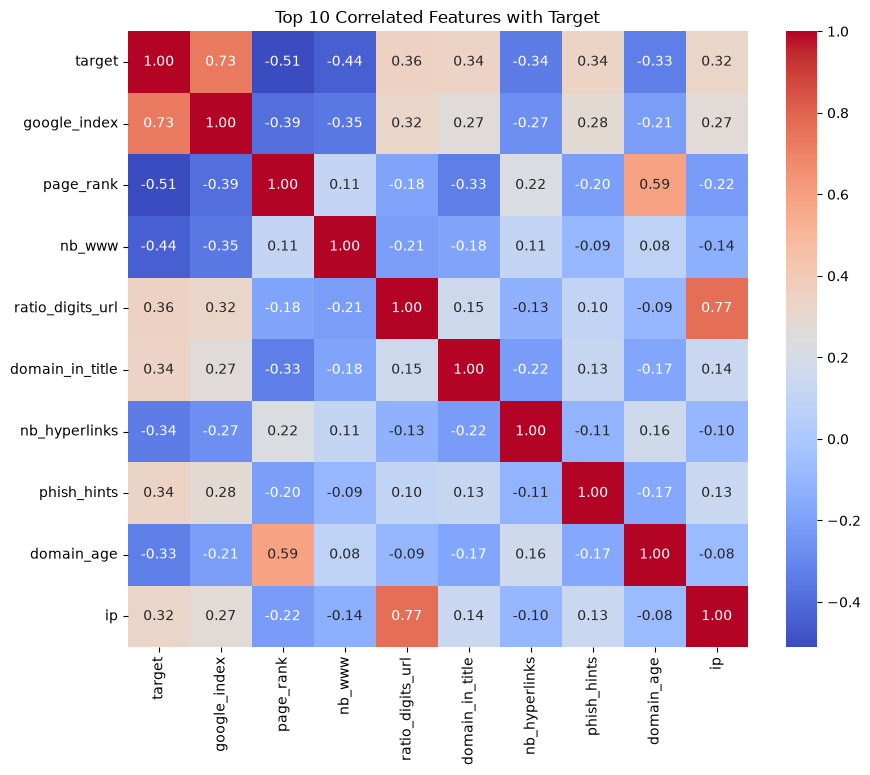

In [25]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Top 10 Correlated Features with Target")
plt.show()

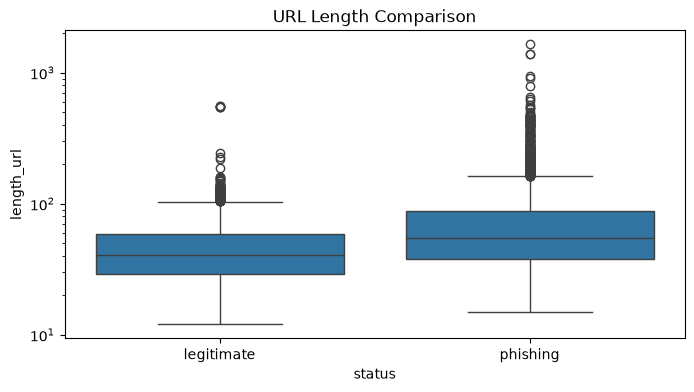

In [26]:
# Boxplot for URL Length by Status
plt.figure(figsize=(8, 4))
sns.boxplot(x='status', y='length_url', data=df)
plt.yscale('log')
plt.title("URL Length Comparison")
plt.show()



# Accuracy of the model


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [28]:
# Random Forest model

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Model Accuracy: 95.93%

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.95      0.96      1143
           1       0.95      0.96      0.96      1143

    accuracy                           0.96      2286
   macro avg       0.96      0.96      0.96      2286
weighted avg       0.96      0.96      0.96      2286



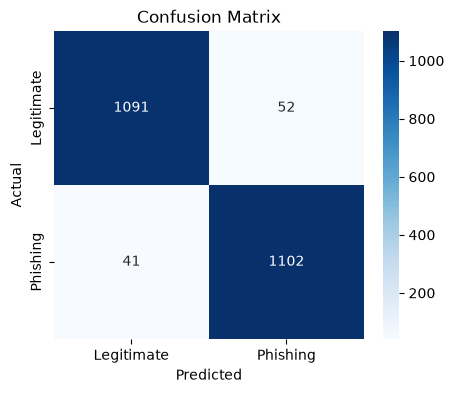

In [29]:
# Calculate accuracy score
acc = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {acc * 100:.2f}%\n")

# Detailed classification report (Precision, Recall, F1-Score)
print("Classification Report:\n", classification_report(y_test, y_pred))

# Plot Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (essential for linear models & SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Initialize models
models = {
    "Logistic Regression": (LogisticRegression(max_iter=1000, random_state=42), True),
    "Decision Tree": (DecisionTreeClassifier(random_state=42), False),
    "Random Forest": (RandomForestClassifier(n_estimators=100, random_state=42), False),
    "Gradient Boosting": (GradientBoostingClassifier(random_state=42), False),
    "Support Vector Machine": (SVC(kernel='rbf', random_state=42), True)
}

results = []

# Train and evaluate each model
for name, (model, requires_scaling) in models.items():
    X_tr = X_train_scaled if requires_scaling else X_train
    X_te = X_test_scaled if requires_scaling else X_test


    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy (%)": round(acc * 100, 2),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4)
    })

# Convert results into a DataFrame
results_df = pd.DataFrame(results).sort_values(by="Accuracy (%)", ascending=False)
print(results_df)

                    Model  Accuracy (%)  Precision  Recall  F1-Score
2           Random Forest         95.93     0.9549  0.9641    0.9595
4  Support Vector Machine         95.41     0.9577  0.9501    0.9539
3       Gradient Boosting         95.28     0.9488  0.9571    0.9530
0     Logistic Regression         93.61     0.9392  0.9326    0.9359
1           Decision Tree         93.39     0.9291  0.9396    0.9343


C:\Users\risha\AppData\Local\Temp\ipykernel_21800\2563775195.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x="Accuracy (%)", y="Model", data=results_df, palette="viridis")


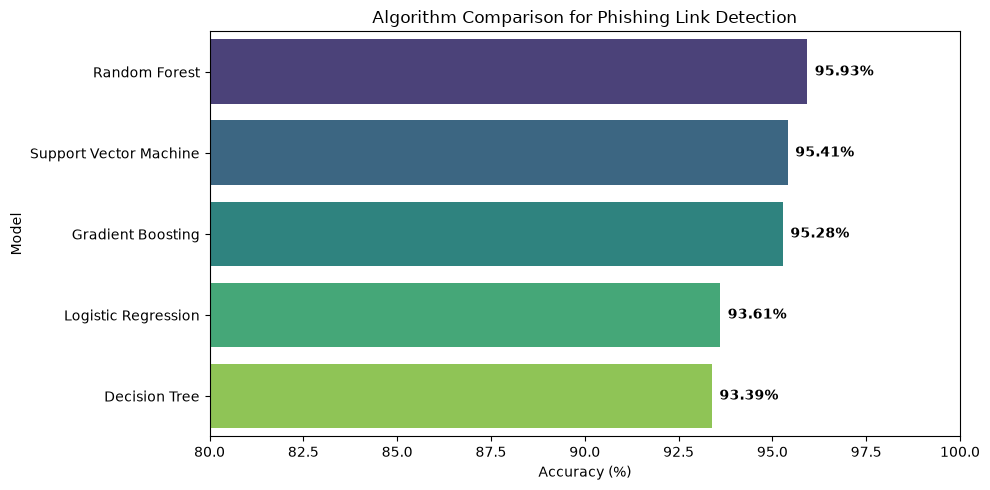

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
bars = sns.barplot(x="Accuracy (%)", y="Model", data=results_df, palette="viridis")
plt.title("Algorithm Comparison for Phishing Link Detection")
plt.xlim(80, 100)

for bar in bars.patches:
    plt.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.2f}%",
        va='center', fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.show()